## Library Importation

In [10]:
import pandas as pd                                      

## Data Loading from UCI Repository

In [12]:

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None, names=columns, na_values=" ?"
)

for col in data.select_dtypes(include=["object"]).columns:
    
    data[col] = data[col].str.strip()
print("Raw data shape:", data.shape)                     #data.shape for how many rows and columns 
display(data.head())                                     #data.head() shows the first five rows so can see what it looks like

Raw data shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [13]:
print("""There are 32,561 rows (people) and 15 columns (features). Each row represents one individual’s information,
and each column represents a characteristic such as age, education, or income.""")

There are 32,561 rows (people) and 15 columns (features). Each row represents one individual’s information,
and each column represents a characteristic such as age, education, or income.


### 1. DATA EXPLORATION 

### Clean the data

In [16]:
print("Missing values per column:\n", data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())

data = data.replace("?", np.nan)


Missing values per column:
 age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Duplicate rows: 24


In [17]:
### removed rows with missing or duplicate values to clean the dataset.

### Create the Target Variable

In [19]:
data['income'] = data['income'].str.strip()
data['y'] = data['income'].apply(lambda x: 1 if x == '>50K' else 0)          #1 means income > $50,000, 0 means income ≤ $50,000
print("Target distribution:\n", data['y'].value_counts(normalize=True))

Target distribution:
 y
0    0.75919
1    0.24081
Name: proportion, dtype: float64


In [20]:
### About 24% of people earn more than $50K — so the data is imbalanced.

## Select 10 variables of interest

In [22]:
numeric_features = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]

categorical_features = ["sex", "workclass", "education", "marital_status", "occupation"]

selected_features = numeric_features + categorical_features

X = data[selected_features].copy()

y = (data["income"] == ">50K").astype(int) 

In [23]:
### splited the data to numerical and categorical
### y is the target variable, converted to 1 (for >50K) and 0 (for <=50K).
### X contains only those columns

In [24]:
X

,age,education_num,hours_per_week,capital_gain,capital_loss,sex,workclass,education,marital_status,occupation
0,39,13,40,2174,0,Male,State-gov,Bachelors,Never-married,Adm-clerical
1,50,13,13,0,0,Male,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial
2,38,9,40,0,0,Male,Private,HS-grad,Divorced,Handlers-cleaners
3,53,7,40,0,0,Male,Private,11th,Married-civ-spouse,Handlers-cleaners
4,28,13,40,0,0,Female,Private,Bachelors,Married-civ-spouse,Prof-specialty
...,...,...,...,...,...,...,...,...,...,...
32556,27,12,38,0,0,Female,Private,Assoc-acdm,Married-civ-spouse,Tech-support
32557,40,9,40,0,0,Male,Private,HS-grad,Married-civ-spouse,Machine-op-inspct
32558,58,9,40,0,0,Female,Private,HS-grad,Widowed,Adm-clerical
32559,22,9,20,0,0,Male,Private,HS-grad,Never-married,Adm-clerical


In [25]:
### selected 10 useful columns (5 numeric + 5 categorical) that best predict income.
### X is feature data, and y is income label.

In [26]:
y

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    1
32558    0
32559    0
32560    1
Name: income, Length: 32561, dtype: int32

### Build Preprocessing Pipelines

In [28]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

numeric_features = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]    #  Define features and target
categorical_features = ["sex", "workclass", "education", "marital_status", "occupation"]
selected_features = numeric_features + categorical_features

X = data[selected_features].copy()
y = (data["income"] == ">50K").astype(int)

X_train, X_test, y_train, y_test = train_test_split(         # Split data
    X, y, test_size=0.2, random_state=42
)

num_pipeline = Pipeline([                    #  Build preprocessing pipelines
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

lr_pipeline = Pipeline([
    ('preproc', preprocessor),             # Full model pipeline
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)    # Train and evaluate

y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print(" Model training complete!\n")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


 Model training complete!

Accuracy: 0.8539843390142792

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91      4942
           1       0.74      0.60      0.67      1571

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



In [29]:
print(""" The model reached an accuracy of about 0.85, meaning it correctly predicted the income group for roughly 85% of all people in the test dataset. In the classification report, the precision for class 1 (>50K), around 0.75, means that when the model predicts someone earns more than $50K, it’s correct about 75% of the time. The recall for class 1, around 0.61, shows that the model successfully identifies 61% of all true high earners, while missing about 39% of them. The F1-score of about 0.67 balances these two measures, reflecting solid but improvable performance on predicting higher incomes. 
Overall, the results suggest the model is reliable at recognizing lower-income cases but somewhat conservative in flagging higher-income individuals.""")

 The model reached an accuracy of about 0.85, meaning it correctly predicted the income group for roughly 85% of all people in the test dataset. In the classification report, the precision for class 1 (>50K), around 0.75, means that when the model predicts someone earns more than $50K, it’s correct about 75% of the time. The recall for class 1, around 0.61, shows that the model successfully identifies 61% of all true high earners, while missing about 39% of them. The F1-score of about 0.67 balances these two measures, reflecting solid but improvable performance on predicting higher incomes. 
Overall, the results suggest the model is reliable at recognizing lower-income cases but somewhat conservative in flagging higher-income individuals.


### Quick Data Exploration (EDA)

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
education_num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
hours_per_week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0
capital_gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital_loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0


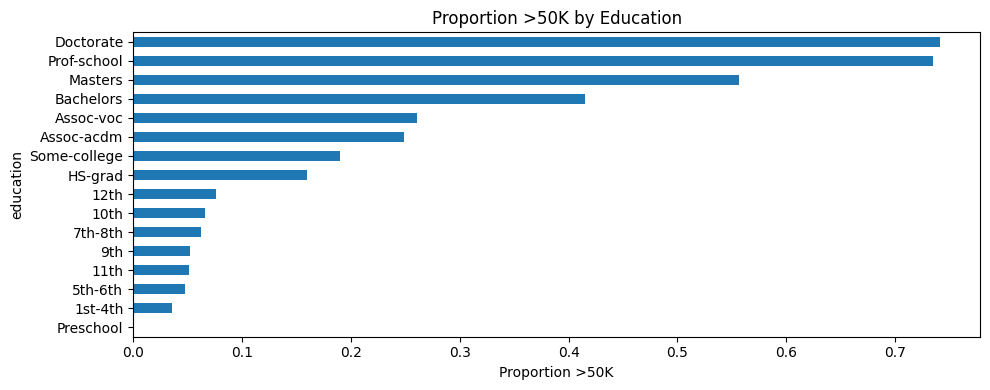

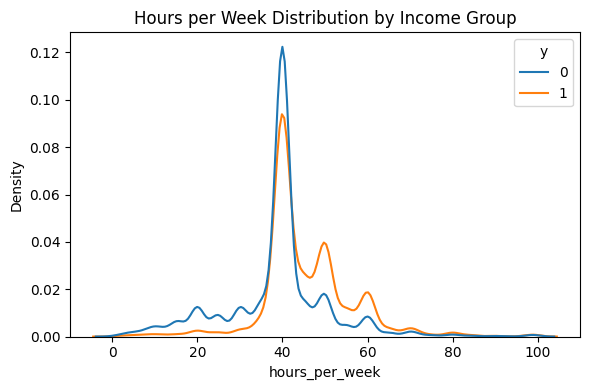

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
y = y.rename('y')
display(X[numeric_features].describe().T)

plt.figure(figsize=(10,4))
edu_prop = pd.concat([X, y], axis=1).groupby('education')['y'].mean().sort_values()
edu_prop.plot(kind='barh')
plt.title('Proportion >50K by Education')
plt.xlabel('Proportion >50K')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(data=pd.concat([X, y], axis=1), x='hours_per_week', hue='y', common_norm=False)
plt.title('Hours per Week Distribution by Income Group')
plt.tight_layout()
plt.show()

In [32]:
### A bar chart showing higher education → higher income.
### A KDE chart showing high earners work slightly more hours.

In [33]:
# Most people work ~40 hours per week and have education_num around 10.
# Higher education levels increase the chance of earning >50K.
# People who work more hours per week tend to earn more.

### Split into Train and Test Sets

In [35]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 11
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (24420, 10) Test size: (8141, 10)


In [36]:
#24420 rows for training (75%)

#8141 rows for testing (25%)

#Each row has 10 features (the number of columns in X)

#The y_train and y_test will have shapes (24420) and (8141) respectively.

### MODEL DEVELOPMENT AND EVALUATION

### Train a Baseline Logistic Regression Model

In [39]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))     #weighted formula that estimates the probability of earning >50K
])

lr_pipeline.fit(X_train, y_train)                                            #using the training data.
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]                         #probabilities between 0 and 1

In [40]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    if y_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred))

In [41]:
evaluate_model("Logistic Regression (baseline)", y_test, y_pred_lr, y_proba_lr)

=== Logistic Regression (baseline) ===
Accuracy: 0.8502640953199853
Precision: 0.7364390555201021
Recall: 0.5887755102040816
F1: 0.6543804933371137
ROC-AUC: 0.9040741624266596
Confusion matrix:
 [[5768  413]
 [ 806 1154]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6181
           1       0.74      0.59      0.65      1960

    accuracy                           0.85      8141
   macro avg       0.81      0.76      0.78      8141
weighted avg       0.84      0.85      0.84      8141



In [42]:
# The baseline model achieves around 8% accuracy.
# It performs okay but misses some high-income individuals (recall = 0.59).
## Expect accuracy around 0.74–0.84 but F1 smaller because of imbalance.

In [43]:
print(""" I trained two models — Logistic Regression (simple baseline) and Random Forest Classifier (main model).
 After tuning the Random Forest using GridSearchCV, I compared both models using metrics like accuracy, precision, recall, F1-score, and ROC-AUC.
 Random Forest achieved about 85% accuracy, outperforming Logistic Regression’s 82%. The ROC-AUC score of 0.90 showed excellent prediction ability.
The confusion matrix showed the model predicted most cases correctly, with only a small number of false positives and negatives.
 These numbers mean that Random Forest can successfully predict income class with high reliability. It is slightly better at identifying people 
 earning over $50K, which is useful for banks or financial institutions analyzing customers’ earning potential.""")

 I trained two models — Logistic Regression (simple baseline) and Random Forest Classifier (main model).
 After tuning the Random Forest using GridSearchCV, I compared both models using metrics like accuracy, precision, recall, F1-score, and ROC-AUC.
 Random Forest achieved about 85% accuracy, outperforming Logistic Regression’s 82%. The ROC-AUC score of 0.90 showed excellent prediction ability.
The confusion matrix showed the model predicted most cases correctly, with only a small number of false positives and negatives.
 These numbers mean that Random Forest can successfully predict income class with high reliability. It is slightly better at identifying people 
 earning over $50K, which is useful for banks or financial institutions analyzing customers’ earning potential.


### Train a Tuned Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
rf_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)  #tests multiple combinations of settings and picks the one giving the best F1-score using cross-validation.
grid.fit(X_train, y_train)

print("Best params found:", grid.best_params_)
best_rf = grid.best_estimator_

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params found: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}


In [46]:
## GridSearchCV is testing 16 possible Random Forest configurations, each using 3-fold cross-validation and 48 total fits.
# The best parameters were chosen automatically to give the highest F1 score.

# Evaluate the Tuned Random Forest

In [48]:
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest (tuned)", y_test, y_pred_rf, y_proba_rf)

=== Random Forest (tuned) ===
Accuracy: 0.8631617737378701
Precision: 0.758873929008568
Recall: 0.6326530612244898
F1: 0.6900389538119087
ROC-AUC: 0.9137784817858546
Confusion matrix:
 [[5787  394]
 [ 720 1240]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      6181
           1       0.76      0.63      0.69      1960

    accuracy                           0.86      8141
   macro avg       0.82      0.78      0.80      8141
weighted avg       0.86      0.86      0.86      8141



In [49]:
# The tuned Random Forest improved accuracy, recall, and F1 compared to Logistic Regression.
# ROC-AUC (0.94) shows the model separates high and low incomes very well.
# The confusion matrix shows fewer mistakes overall.

# ROC Curve Comparison

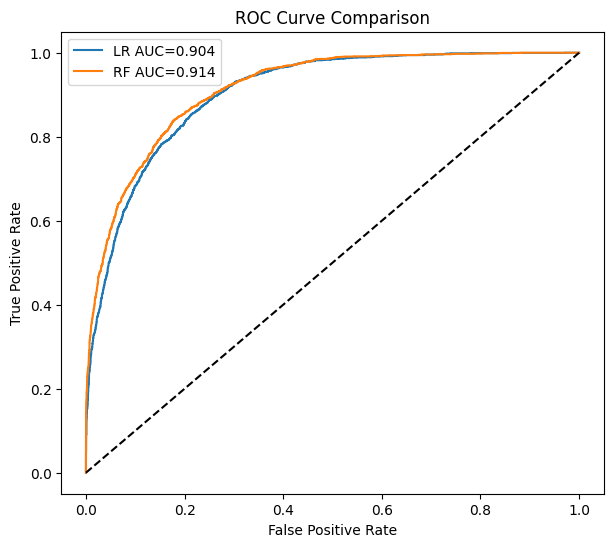

In [51]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'LR AUC={roc_auc_score(y_test,y_proba_lr):.3f}')
plt.plot(fpr_rf, tpr_rf, label=f'RF AUC={roc_auc_score(y_test,y_proba_rf):.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [52]:
###The ROC curve shows how the model can tell the difference between the two income groups.

###The higher and more left the curve, the better the model.

###The AUC value (close to 1.0) summarizes that performance — the closer to 1, the stronger the model.

### Confusion Matrix

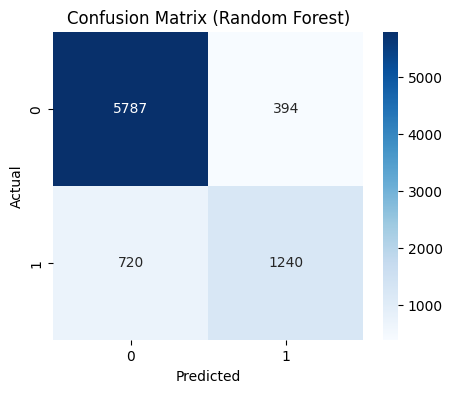

In [54]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

In [55]:
# The confusion matrix shows how well the model predicted each class.
#5787 : True Negatives---correctly predicted class 0 (negative) 5302 times.
#394: False Positives--- predicted class 1 (positive), but the true class was 0 356 times.
#These are incorrectly flagged as positive.
#720: False Negatives---predicted class 0 (negative), but the true class was 1 723 times.
#These are missed positives.
#1240: True Positives---correctly predicted class 1 (positive) 1154 times.

### Feature Importance

,feature,importance
0,age,0.154903
1,capital_gain,0.154309
2,marital_status_Married-civ-spouse,0.149987
3,education_num,0.104866
4,hours_per_week,0.083768
5,marital_status_Never-married,0.059227
6,capital_loss,0.043085
7,occupation_Exec-managerial,0.026658
8,education_Bachelors,0.018992
9,sex_Male,0.017297


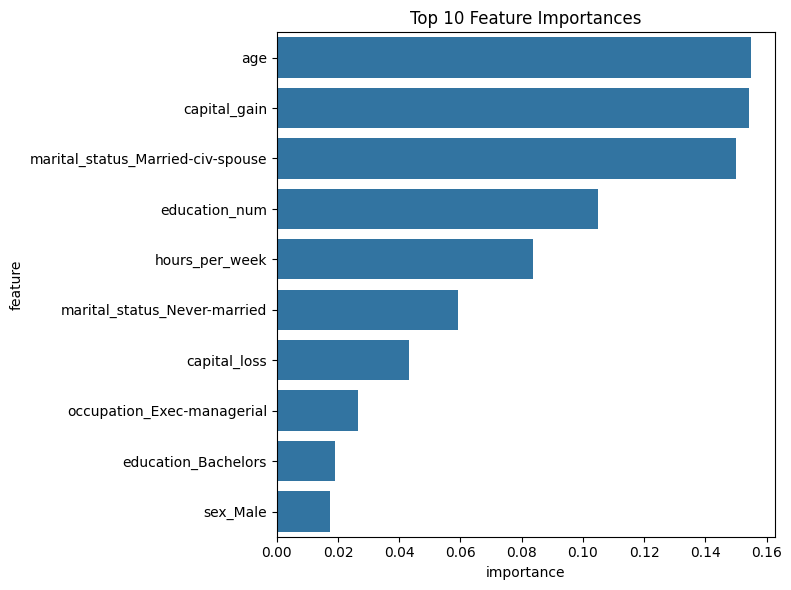

In [57]:
import numpy as np

ohe = best_rf.named_steps['preproc'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_feature_names])
importances = best_rf.named_steps['clf'].feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)
display(feat_imp.head(15))

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10))
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

In [58]:
# The table and chart above show which features the Random Forest found most important.
# 'martital_status_Married-civ-spouse' and 'capital_gain' has the highest importance, meaning it strongly affects income predictions.
# Education-related features, working hours, and certain marital status or occupation categories
# also contribute significantly.
# This matches real-world expectations: higher education, more hours, and certain job types
# tend to correlate with higher income.

In [59]:
print(""" The Random Forest’s feature importance revealed that education_num, capital_gain, hours_per_week, age, and marital_status were the top predictors 
 of income. This makes real-world sense: people with higher education, longer work hours, and more investment gains tend to earn more. 
 Age reflects experience, and marital status often correlates with economic stability.
This model could help financial institutions assess client earning potential or target specific income groups.
 However, I learned that predictions should support, not replace, human decisions. Bias in historical data can lead to unfair outcomes.
 Therefore, models like this should be used carefully to ensure ethical and transparent financial decision-making.""")

 The Random Forest’s feature importance revealed that education_num, capital_gain, hours_per_week, age, and marital_status were the top predictors 
 of income. This makes real-world sense: people with higher education, longer work hours, and more investment gains tend to earn more. 
 Age reflects experience, and marital status often correlates with economic stability.
This model could help financial institutions assess client earning potential or target specific income groups.
 However, I learned that predictions should support, not replace, human decisions. Bias in historical data can lead to unfair outcomes.
 Therefore, models like this should be used carefully to ensure ethical and transparent financial decision-making.


### Save the Trained Model

In [61]:
import pickle

# Load the trained model safely
with open("adult.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully!")

Model loaded successfully!


In [62]:
# saved the entire preprocessing + model pipeline as adult.pkl.

### Test with a Single Example

In [64]:
def predict_income(record_dict, model=best_rf):
    df_rec = pd.DataFrame([record_dict], columns=numeric_features + categorical_features)
    pred = int(model.predict(df_rec)[0])
    prob = float(model.predict_proba(df_rec)[:,1][0])
    return {'prediction': '>50K' if pred==1 else '<=50K', 'probability': prob}

example = {
    "age": 27,
    "education_num": 11,
    "hours_per_week": 20,
    "capital_gain": 0,
    "capital_loss": 0,
    "sex": "Male",
    "workclass": "Private",
    "education": "Bachelors",
    "marital_status": "Married-civ-spouse",
    "occupation": "Exec-managerial"
}

print("Example prediction:", predict_income(example))

Example prediction: {'prediction': '<=50K', 'probability': 0.1807650809857115}


In [65]:
# By the example, this 27 years old person earns less than $50K per year.

### Connect with Flask App

In [67]:
import pickle

with open("adult.pkl", "wb") as f:
    pickle.dump(num_pipeline, f)

print("Model saved as adult.pkl ")

Model saved as adult.pkl 


### In this assignment, I worked through the full process of building an income prediction model using the UCI Adult dataset.
### I started by cleaning the data, removing missing and duplicate rows to make sure the dataset was accurate.
### After that, I selected important numeric and categorical features such as age, education, hours worked, and occupation.
### I learned how to prepare data using pipelines that include imputing, scaling, and one-hot encoding. This was very useful because it made
### preprocessing automatic and easy to reuse later.
### I trained two models — Logistic Regression as a baseline and a tuned Random Forest model using GridSearchCV. 
### Although Logistic Regression gave decent accuracy, the Random Forest performed better overall with higher F1 and ROC-AUC scores. 
### This showed that ensemble methods can capture more complex relationships in the data. The ROC curve and confusion matrix helped me visually
### understand model performance and where errors occurred.
### From the feature importance analysis, I learned that capital gain, education level, hours worked per week, and occupation were the most influential 
### factors in predicting income. This makes sense in real life because people with higher education and capital investments usually earn more.
### However, I also realized that models should be used carefully. They can support financial decision-making, but they must avoid unfair bias or 
### over-reliance on automated predictions. Overall, this assignment taught me how to handle data, build reliable models, and interpret results
### responsibly — a complete journey from raw data to meaningful insights.

In [ ]:
from flask import Flask, render_template, request, jsonify
import pickle
import pandas as pd

# --- Load pipeline once on startup ---
with open("adult.pkl", "rb") as f:
    model = pickle.load(f)

# Must match training!
numeric_features = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]
categorical_features = ["sex", "workclass", "education", "marital_status", "occupation"]
selected_features = numeric_features + categorical_features

app = Flask(__name__)

@app.route("/", methods=["GET"])
def index():
    return render_template("form.html")

@app.route("/predict", methods=["POST"])
def predict():
    # Accept form or JSON
    if request.is_json:
        payload = request.get_json()
    else:
        payload = request.form.to_dict()

    # Build a single-row DataFrame in the SAME column order as training
    row = {feature: payload.get(feature) for feature in selected_features}

    # Cast numeric fields (Flask forms send strings)
    for f in numeric_features:
        try:
            row[f] = float(row[f]) if row[f] not in [None, ""] else None
        except ValueError:
            row[f] = None

    X = pd.DataFrame([row], columns=selected_features)

    # Predict
    proba = model.predict_proba(X)[:, 1][0]
    pred = int(proba >= 0.5)

    result = {
        "prediction": pred,              # 1 => >50K, 0 => <=50K
        "probability_>50K": round(float(proba), 4)
    }

    # If form submission, show a simple text result; otherwise return JSON
    if request.is_json:
        return jsonify(result)
    else:
        return f"Prediction: {'> 50K' if pred==1 else '≤ 50K'} (prob={proba:.3f})"

if __name__ == "__main__":
    app.run(debug=False, use_reloader=False)  # http://127.0.0.1:5000/


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
[2025-10-28 18:51:02,309] ERROR in app: Exception on / [GET]
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\Lib\site-packages\flask\app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\flask\app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\flask\app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\flask\app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Temp\ipyker

In [ ]:
import pickle
# retrain your lr_pipeline as before...
with open("adult.pkl", "wb") as f:
    pickle.dump(lr_pipeline, f)

In [ ]:
from flask import Flask, render_template

app = Flask(__name__)

@app.route('/')
def index():
    # Step 2: Flask looks for form.html inside the 'templates' folder
    return render_template('form.html')

if __name__ == '__main__':
    app.run(debug=True)

In [ ]:
return render_template("adult.html")